<a href="https://colab.research.google.com/github/TomerL44/CloudCompEX/blob/main/Tirgulum/Tirgul10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

+--------+--------+-------+-------+--------+--------+
|min_temp|max_temp|min_hum|max_hum|min_soil|max_soil|
+--------+--------+-------+-------+--------+--------+
|    17.4|    26.6|   27.0|   57.0|     8.0|   100.0|
+--------+--------+-------+-------+--------+--------+



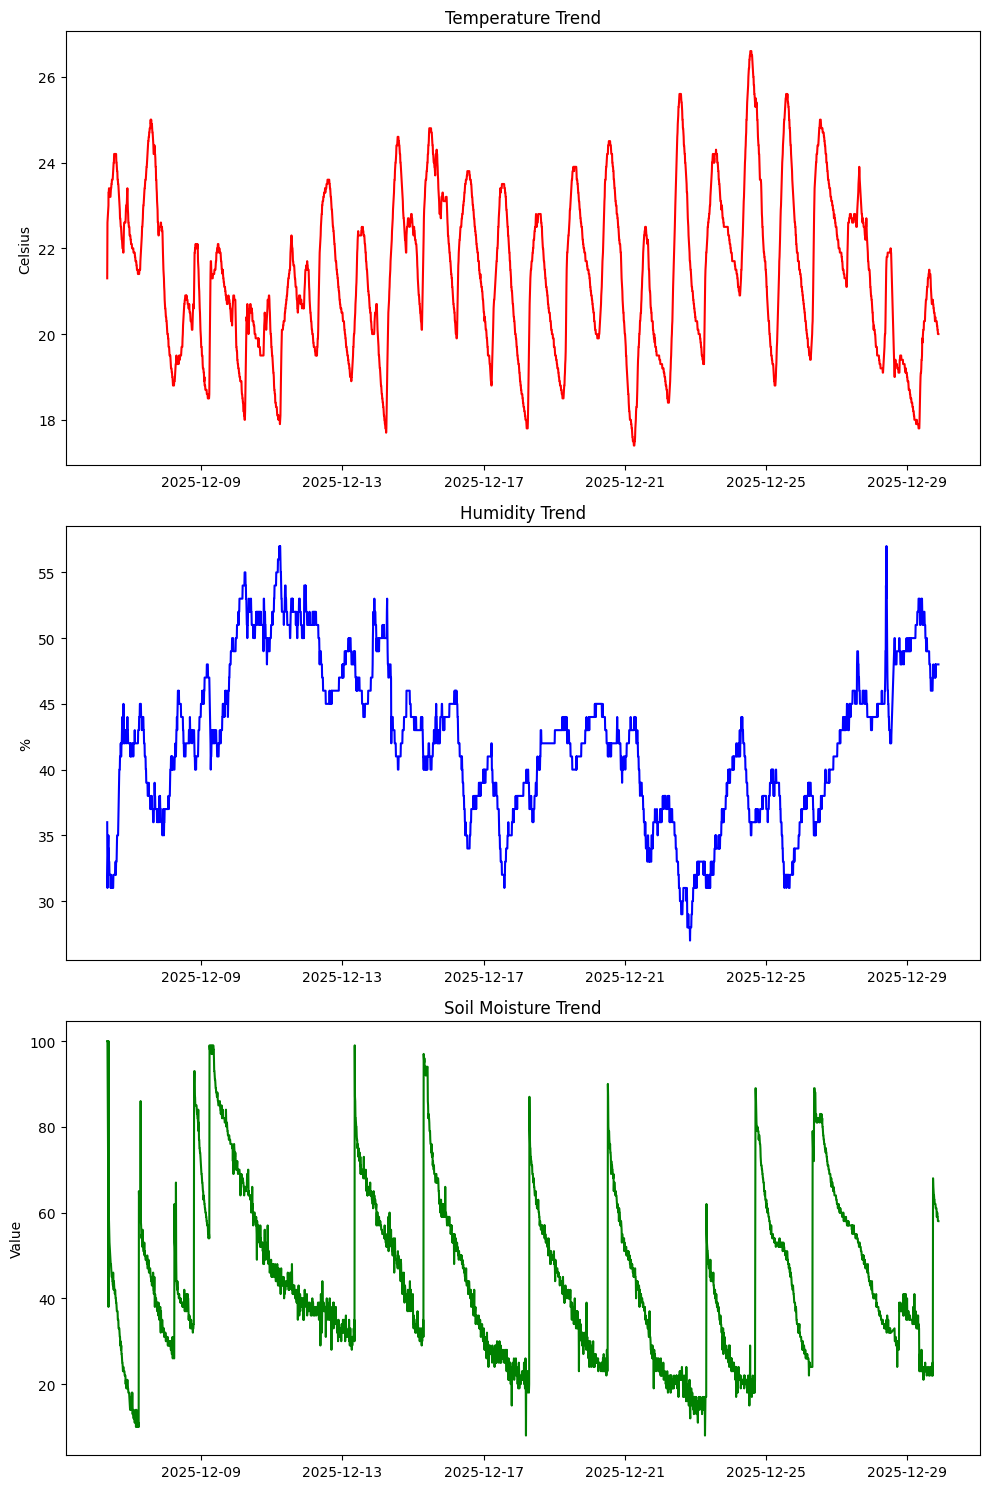

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, min, max
from pyspark.sql.types import StructType, StructField, DoubleType
import matplotlib.pyplot as plt
import pandas as pd


spark = SparkSession.builder.appName("SensorAnalysis").getOrCreate()


schema = StructType([
    StructField("temperature", DoubleType(), True),
    StructField("humidity", DoubleType(), True),
    StructField("soil", DoubleType(), True)
])

df = spark.read.json("/content/drive/MyDrive/json-20251229-2107.json")
df_processed = df.withColumn("data", from_json(col("value"), schema)).select("data.*", "created_at")


stats = df_processed.agg(
    min("temperature").alias("min_temp"), max("temperature").alias("max_temp"),
    min("humidity").alias("min_hum"), max("humidity").alias("max_hum"),
    min("soil").alias("min_soil"), max("soil").alias("max_soil")
)

stats.show()


pandas_df = df_processed.toPandas()
pandas_df['created_at'] = pd.to_datetime(pandas_df['created_at'])
pandas_df = pandas_df.sort_values('created_at')





fig, axes = plt.subplots(3, 1, figsize=(10, 15))


axes[0].plot(pandas_df['created_at'], pandas_df['temperature'], color='red')
axes[0].set_title('Temperature Trend')
axes[0].set_ylabel('Celsius')


axes[1].plot(pandas_df['created_at'], pandas_df['humidity'], color='blue')
axes[1].set_title('Humidity Trend')
axes[1].set_ylabel('%')

axes[2].plot(pandas_df['created_at'], pandas_df['soil'], color='green')
axes[2].set_title('Soil Moisture Trend')
axes[2].set_ylabel('Value')

plt.tight_layout()
plt.show()